In [238]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import scipy.io
import os
import re
from utils import *
import psana

In [244]:
###############################################
runNumbers = [298]  # enter the run numbers to be loaded
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/' # insert here the directory path where .h5 files are stored
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/'
folder = '/sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/'
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = [#'CXI-DG2-BMMON-WF/ROI_area',
                    'jungfrau4M/azav_mask0_azav', # Unfiltered
                   'jungfrau4M/azav_mask1_azav', # Filtered
                   'dg2ipmReproc/sum',
                   'dg2ipmReproc/peaks',
                   'dg2ipmReproc/xpos',
                   'dg2ipmReproc/ypos',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/xray',
                  'jungfrau4M/Full_thres_sum',
                  'feeBld/hproj',
                  'lightStatus/laser',
                   'ipm_dg2/sum',
                    'ipm_hfx_dg2/sum',
                   'event_time',
                   'epicsUser/gasCell_pressure',
                   'fiducials'
                  ]

keys_to_sum = ['Sums/jungfrau4M_calib']
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q',
                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq',
                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q', # This are only needed once
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi', # This are only needed once
                'UserDataCfg/jungfrau4M/x',
                'UserDataCfg/jungfrau4M/y',
                'UserDataCfg/jungfrau4M/z',
                'UserDataCfg/jungfrau4M/cmask']
# Load the data in
data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

# Filtered Data
azavFiltered = np.squeeze(data['jungfrau4M/azav_mask0_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbinFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin'] # q bin-size
qFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q'] # q bins 
qbinsFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins'] # q bins
userMaskFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask'].astype(bool) # User mask for this region
qbinSizeFiltered = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq'])
# Unfiltered Data
azav = np.squeeze(data['jungfrau4M/azav_mask1_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbin = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin'] # q bin-size
q = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q'] # q bins 
qbins = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins'] # q bins
userMask = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask'].astype(bool) # User mask for this region
qbinSize = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq'])
# Other Data
matrix_q = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q'].reshape(8,512,1024) # Q values J4M shaped
matrix_phi = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi'].reshape(8,512,1024) # phi valyes J4M shaped
xrayOn = data['evr/code_137'].astype(bool)  # xray on events
xrayOn2 = data['lightStatus/xray'].astype(bool)  # xray on events
laserOn = data['lightStatus/laser'].astype(bool)  # xray on events
jungfrau_sum = data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
#jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = data['UserDataCfg/jungfrau4M/y']
z = data['UserDataCfg/jungfrau4M/z'] 

cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
run_indicator = data['run_indicator'] # run indicator for each shot
#pressure = data['epicsAll/gasCell_pressure']  # pressure in gas cell
xray_energy = data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
xray_eV = data['ebeam/photon_energy']    # x-ray energy energy in eV|
numPhotons = data['jungfrau4M/Full_thres_sum']
spec = data['feeBld/hproj'] # Shot to shot spectrometer
#dg2traces = data['CXI-DG2-BMMON-WF/ROI_area'] # Downsampling by a factor of 8, makes the refitting much better in the long run
gasPressure = data['epicsUser/gasCell_pressure']
eventTime = data['event_time']
fid = data['fiducials']
ipm = data['dg2ipmReproc/sum']
ipmpeaks = data['dg2ipmReproc/peaks']
xpos = data['dg2ipmReproc/xpos']
ypos = data['dg2ipmReproc/ypos']
# hfxSum = data['ipm_hfx_dg2/sum']
#dg2tracesFull = data['CXI-DG2-BMMON-WF/ROI_rebin_data']
del data

# For some reason we need to offet the data by one. Will this be a problem in later experiments?
spec = spec[0:-2];
azavFiltered = azavFiltered[1:-1];
azav = azav[1:-1];
xrayOn = xrayOn[1:-1];
xrayOn2 = xrayOn2[1:-1];
laserOn = laserOn[1:-1];
ipm = ipm[1:-1];
ipmpeaks = ipmpeaks[1:-1];
xpos = xpos[1:-1];
ypos = ypos[1:-1];

eventTime = eventTime[1:-1];
gasPressure = gasPressure[1:-1];
fid = fid[1:-1];

Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0298.h5
Loaded Data


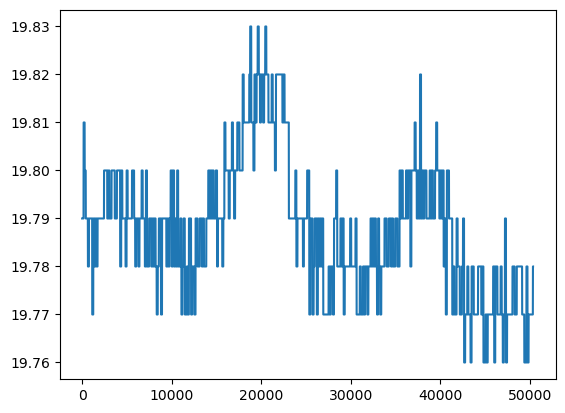

In [256]:
plt.plot(gasPressure);

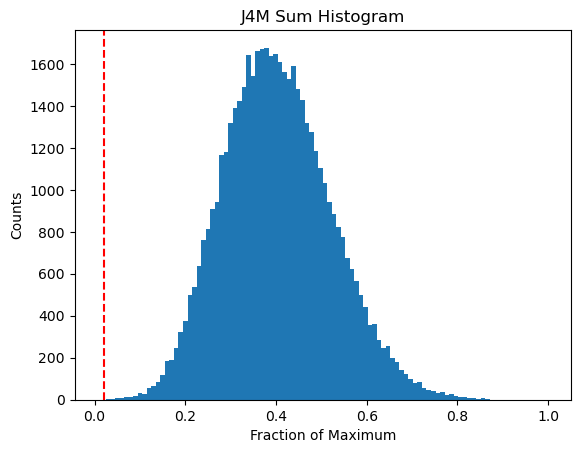

In [245]:
##########
integration_cutoff_hb = 0.2
integration_cutoff_lb = 0.05
scattering_cutoff = 0.02
##########
scattered_xrays = np.sum(azav,axis=-1)
#scattered_xraysFiltered = np.sum(azavFiltered*qbinSizeFiltered,axis=-1)

plt.hist(scattered_xrays/scattered_xrays.max(),bins=100);
plt.axvline(scattering_cutoff,color='r',linestyle='--')
plt.title('J4M Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.show()
# Doing the actual filtering
goodIdx = (xrayOn2) & (scattered_xrays/scattered_xrays.max()>scattering_cutoff) & (~np.isnan(scattered_xrays))
specGood = spec[goodIdx]
#dg2Good = dg2traces[goodIdx]
J4MSum = scattered_xrays[goodIdx]
gasPGood = gasPressure[goodIdx]
ipmGood = ipm[goodIdx]

In [75]:
Sum, Xpos, Ypos, _ = recalculateDG2IPM(dg2Good,800,1000)
del dg2Good

In [240]:
def hist2dLinFit(xdata,ydata,bins):
    plt.figure(figsize=[12,10])
    poly_coeffs = np.polyfit(xdata, ydata, 1)
    print(poly_coeffs)
    # Generate fit curve
    x_fit = np.linspace(np.min(xdata), np.max(xdata), 100)
    y_fit = np.polyval(poly_coeffs, x_fit)
    
    rcoeff = scipy.stats.pearsonr(xdata, ydata)
    plt.text(0.1, 0.8, f'Pearson r coeff: {rcoeff.statistic:.9f}',
             fontsize=18, fontweight='bold', transform=plt.gca().transAxes, ha='left', color='White')
    
    
    plt.hist2d(xdata,ydata,bins, zorder=1);
    # Overlay the fit curve
    plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear Fit', linestyle='--',zorder=2)
    plt.legend()
    plt.show();

[ 5.08086983e-03 -8.40828354e+00]


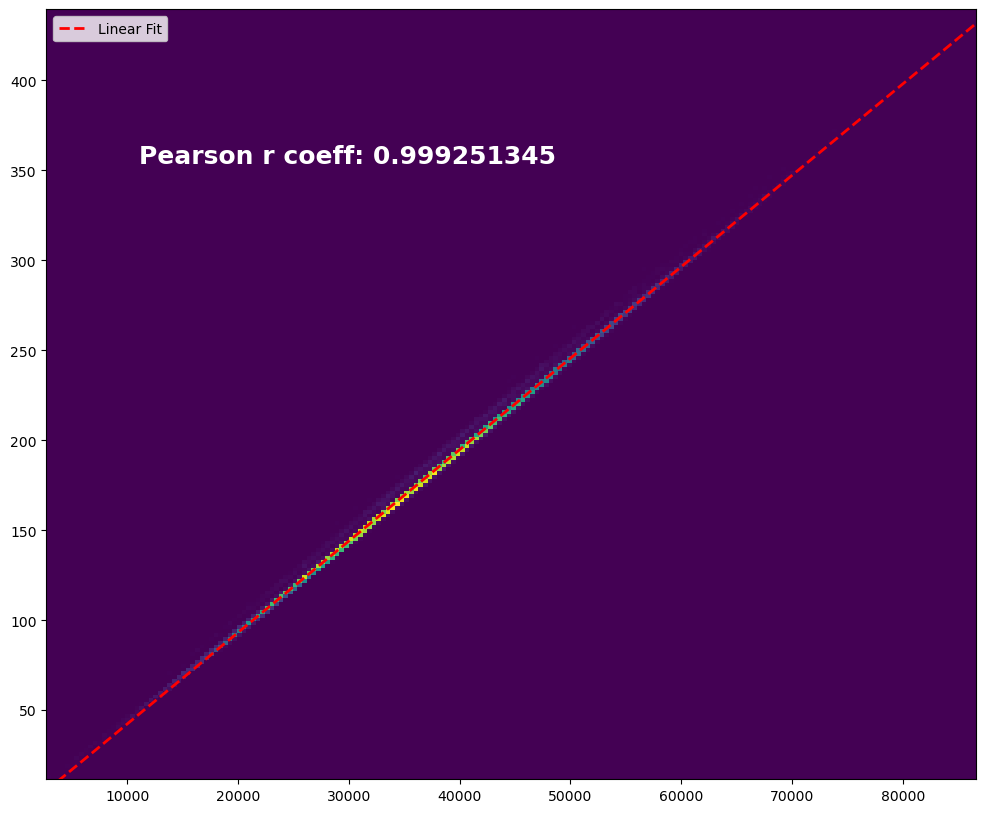

In [255]:
hist2dLinFit(ipmGood,J4MSum,200);

[ 2.56816161e-04 -4.26690435e-01]


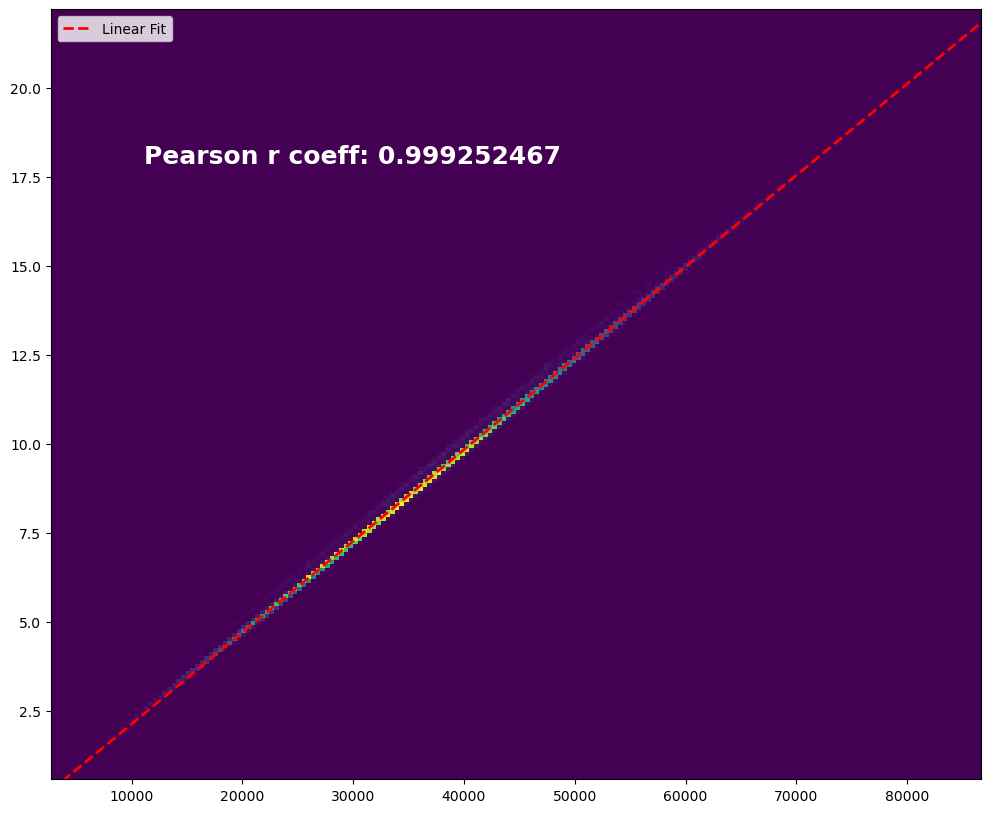

In [249]:
hist2dLinFit(ipmGood,(J4MSum/gasPGood),200)

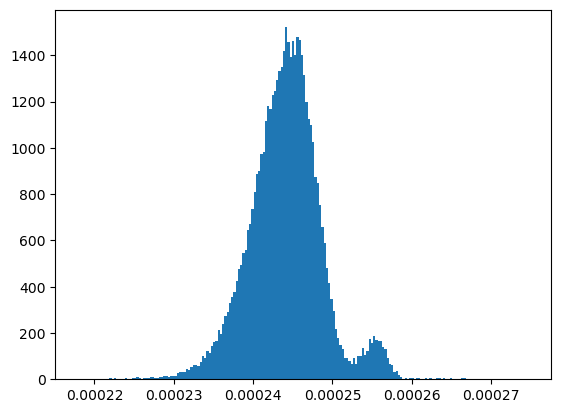

In [250]:
plt.hist((J4MSum/gasPGood)/ipmGood,200);

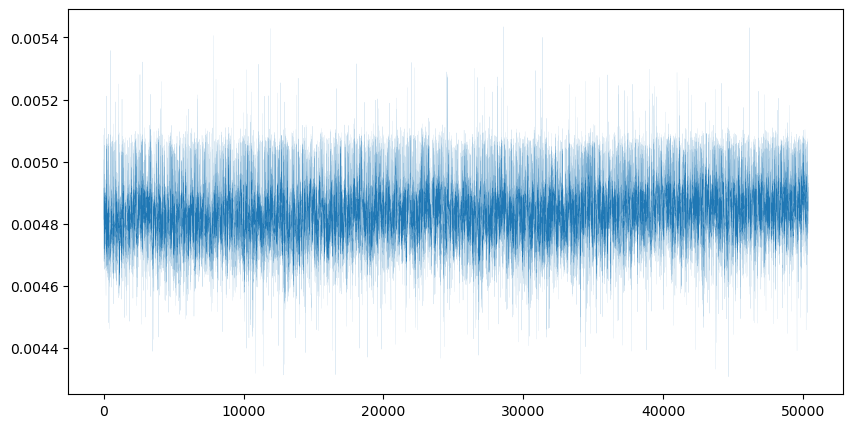

In [252]:
plt.figure(figsize=[10,5])
plt.plot((J4MSum)/ipmGood,linewidth=0.05)

In [229]:
import psana
import numpy as np
##########################
runNumber=191
experiment='cxil1037623'
nTotEvents = 3609
##########################
dsname = 'exp=%s:run=%d:smd' % (experiment , runNumber) 
ds = psana.DataSource(dsname)
# LCLS1 uses 3 numbers to define an event.  In LCLS2 this is one number.
seconds     = []
nanoseconds = []
fiducials   = []

# get some times of events (these could come from a saved "small data" file, for example)
for nevent,evt in enumerate(ds.events()):
    # evtId = evt.get(EventId)
    # seconds.append(evtId.time()[0])
    # nanoseconds.append(evtId.time()[1])
    # fiducials.append(evtId.fiducials())
    # if nevent==2: break
    nevent;

2025-03-21 11:51:36.565 [WRN] {XtcInput.XtcStreamDgIter} XtcStreamDgIter.cpp:299 - control stream has two datagrams with the same seconds/nanoseconds timestamp. The latter one is not marked as a split event. REMOVING the existing one, and Discarding the latter one: path=/sdf/data/lcls/ds/cxi/cxil1037623/xtc/smalldata/cxil1037623-r0191-s80-c00.smd.xtc offset=4946910 sec=1740939879 nano=854939313 fiducials=87729 transition=L1Accept
2025-03-21 11:51:36.572 [WRN] {XtcInput.XtcStreamDgIter} XtcStreamDgIter.cpp:299 - control stream has two datagrams with the same seconds/nanoseconds timestamp. The latter one is not marked as a split event. REMOVING the existing one, and Discarding the latter one: path=/sdf/data/lcls/ds/cxi/cxil1037623/xtc/smalldata/cxil1037623-r0191-s80-c00.smd.xtc offset=4956262 sec=1740939879 nano=996628196 fiducials=87780 transition=L1Accept


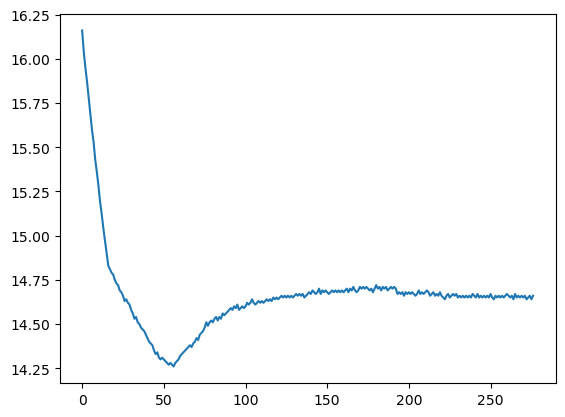

In [139]:
plt.plot(pressure)

In [138]:
from datetime import datetime, timedelta, timezone
from epicsArch import *
# Initialize the EpicsArchive object
archive = EpicsArchive()
pv = 'CXI:MKS670:READINGGET'
start_time = 1740939816
end_time = 1740940236.7
unit = "seconds"  # Time unit
[times,pressure] = archive.get_points(PV=pv, start=start_time, end=end_time,unit="seconds",raw=True,two_lists=True);

DEBUG:epicsArch:URL: https://pswww.slac.stanford.edu/archiveviewer/retrieval/data/getData.json?pv=CXI:MKS670:READINGGET&from=2025-03-02T18:23:36.000Z&to=2025-03-02T18:30:36.000Z&donotchunk
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): pswww.slac.stanford.edu:443
DEBUG:urllib3.connectionpool:https://pswww.slac.stanford.edu:443 "GET /archiveviewer/retrieval/data/getData.json?pv=CXI:MKS670:READINGGET&from=2025-03-02T18:23:36.000Z&to=2025-03-02T18:30:36.000Z&donotchunk HTTP/11" 200 None


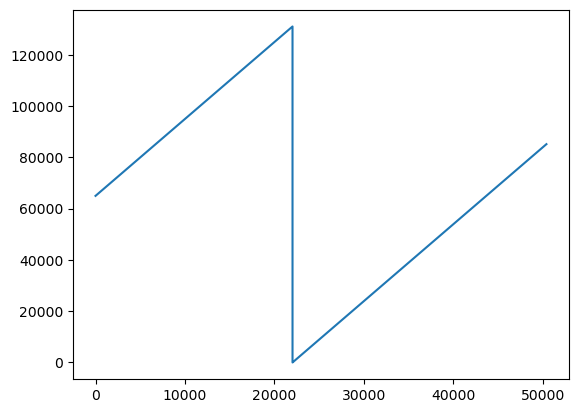

In [187]:
plt.plot(fid)

In [216]:
slopes = np.zeros(1000)
for i in range(0,1000):
    slopes[i]=eventTime[i+1]/1e9-eventTime[i]/1e9

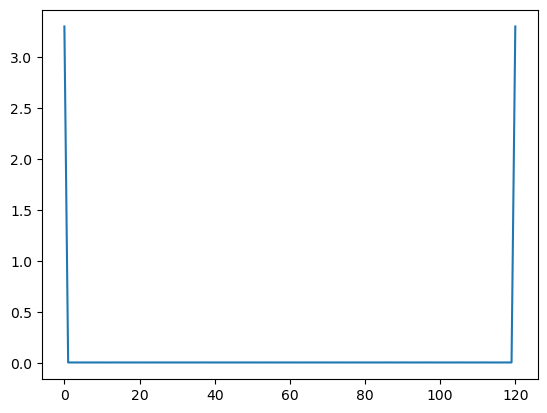

In [217]:
plt.plot(slopes[40:161])

In [218]:
slopes[160]

3.303272247314453

In [226]:
eventTime[39]

7477279575012553556

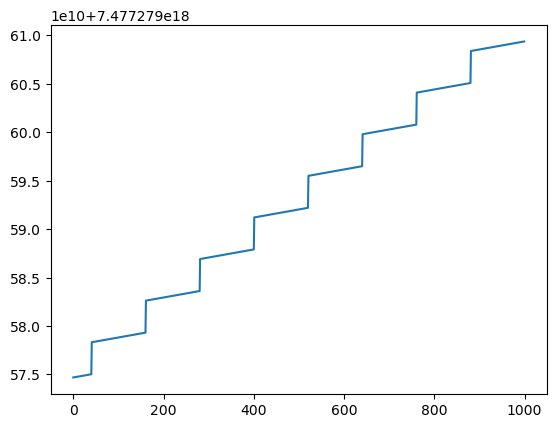

In [220]:
plt.plot(eventTime[0:1000]) 

0.008284735